In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extract done")

Extract done


In [7]:
from PIL import Image

def clean_dataset(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path).convert("RGB")
                img.verify()
            except:
                os.remove(path)
                removed += 1
    print("Removed:", removed)

clean_dataset("/content/dataset")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Removed: 0


In [8]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

In [9]:
def create_dataset(data_dir):
    file_paths = []
    labels = []

    class_names = sorted(os.listdir(data_dir))

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        for file in os.listdir(class_dir):
            file_paths.append(os.path.join(class_dir, file))
            labels.append(label)

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    ds = ds.map(lambda x, y: process_path(x, y),
                num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.apply(tf.data.experimental.ignore_errors())

    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds, class_names

In [11]:
train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"

train_ds, class_names = create_dataset(train_dir)
val_ds, _ = create_dataset(val_dir)

print("Classes:", class_names)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Classes: ['Capacitor', 'IC', 'Transistor']


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('my_model.h5', monitor='val_loss', save_best_only=True)
]

# Giai đoạn 1: Chỉ train lớp Phân loại mới thêm vào
print("--- GIAI ĐOẠN 1: HUẤN LUYỆN LỚP PHÂN LOẠI TOP ---")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

# Giai đoạn 2: Mở băng các lớp trên cùng của MobileNetV2 để Fine-tune
print("\n--- GIAI ĐOẠN 2: FINE-TUNING MÔ HÌNH ---")
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

--- GIAI ĐOẠN 1: HUẤN LUYỆN LỚP PHÂN LOẠI TOP ---
Epoch 1/5
     82/Unknown 38s 333ms/step - accuracy: 0.7848 - loss: 0.5637

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


83/83 ━━━━━━━━━━━━━━━━━━━━ 50s 473ms/step - accuracy: 0.8769 - loss: 0.3239 - val_accuracy: 0.9867 - val_loss: 0.0405
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 432ms/step - accuracy: 0.9035 - loss: 0.2686 - val_accuracy: 0.9841 - val_loss: 0.0421
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 461ms/step - accuracy: 0.9152 - loss: 0.2233 - val_accuracy: 0.9881 - val_loss: 0.0413
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 82s 457ms/step - accuracy: 0.9274 - loss: 0.2118 - val_accuracy: 0.9881 - val_loss: 0.0411
Epoch 5/5
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8975 - loss: 0.2939

83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 486ms/step - accuracy: 0.9422 - loss: 0.1779 - val_accuracy: 0.9920 - val_loss: 0.0390

--- GIAI ĐOẠN 2: FINE-TUNING MÔ HÌNH ---
Epoch 1/5
     82/Unknown 57s 333ms/step - accuracy: 0.8734 - loss: 0.3122

83/83 ━━━━━━━━━━━━━━━━━━━━ 71s 492ms/step - accuracy: 0.9331 - loss: 0.1819 - val_accuracy: 0.9907 - val_loss: 0.0378
Epoch 2/5
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.8943 - loss: 0.2766

83/83 ━━━━━━━━━━━━━━━━━━━━ 48s 463ms/step - accuracy: 0.9396 - loss: 0.1673 - val_accuracy: 0.9920 - val_loss: 0.0368
Epoch 3/5
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8992 - loss: 0.2667

83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 462ms/step - accuracy: 0.9479 - loss: 0.1480 - val_accuracy: 0.9920 - val_loss: 0.0356
Epoch 4/5
82/83 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9087 - loss: 0.2508

83/83 ━━━━━━━━━━━━━━━━━━━━ 82s 467ms/step - accuracy: 0.9502 - loss: 0.1434 - val_accuracy: 0.9947 - val_loss: 0.0350
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 46s 441ms/step - accuracy: 0.9590 - loss: 0.1276 - val_accuracy: 0.9920 - val_loss: 0.0372


In [15]:
model.save("/content/drive/MyDrive/my_model.h5")

--- ĐỒ THỊ QUÁ TRÌNH HUẤN LUYỆN ---


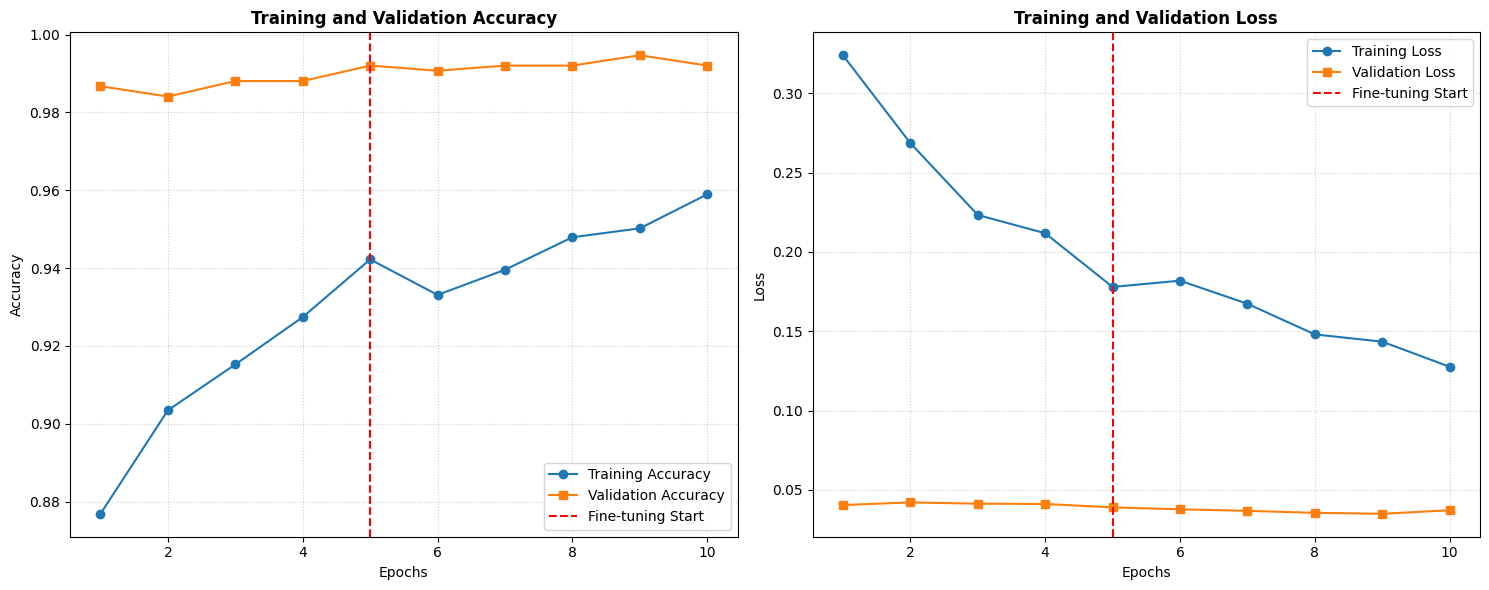

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------------
# 1. VẼ SƠ ĐỒ QUÁ TRÌNH TRAIN MODEL (LOSS & ACCURACY)
# ------------------------------------------------------------------
def plot_training_history(history_dict, warmup_epochs=None):
    acc = history_dict.get('accuracy', [])
    val_acc = history_dict.get('val_accuracy', [])
    loss = history_dict.get('loss', [])
    val_loss = history_dict.get('val_loss', [])
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='#1f77b4')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', color='#ff7f0e')

    if warmup_epochs and warmup_epochs < len(acc):
        plt.axvline(x=warmup_epochs, color='red', linestyle='--', linewidth=1.5, label='Fine-tuning Start')

    plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # Đồ thị Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='#1f77b4')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s', color='#ff7f0e')

    if warmup_epochs and warmup_epochs < len(loss):
        plt.axvline(x=warmup_epochs, color='red', linestyle='--', linewidth=1.5, label='Fine-tuning Start')

    plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

print("--- ĐỒ THỊ QUÁ TRÌNH HUẤN LUYỆN ---")

warmup_epochs_count = len(history_warmup.history.get('accuracy', []))

combined_history_dict = {}
for key in history_warmup.history.keys():
    combined_history_dict[key] = history_warmup.history[key] + history_finetune.history[key]

plot_training_history(combined_history_dict, warmup_epochs=warmup_epochs_count)

In [17]:
# ------------------------------------------------------------------
# 2. DỰ ĐOÁN TRÊN TẬP VALIDATION ĐỂ LÀM BÁO CÁO & CONFUSION MATRIX
# ------------------------------------------------------------------
print("\n--- ĐANG TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP VALIDATION ---")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ------------------------------------------------------------------
# 3. BÁO CÁO PHÂN TÍCH (CLASSIFICATION REPORT)
# ------------------------------------------------------------------
print("\n--- BÁO CÁO PHÂN TÍCH CHI TIẾT (CLASSIFICATION REPORT) ---")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


--- ĐANG TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP VALIDATION ---

--- BÁO CÁO PHÂN TÍCH CHI TIẾT (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

   Capacitor       1.00      0.97      0.99       276
          IC       0.99      0.99      0.99       271
  Transistor       0.96      0.99      0.97       207

    accuracy                           0.98       754
   macro avg       0.98      0.98      0.98       754
weighted avg       0.98      0.98      0.98       754




--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---


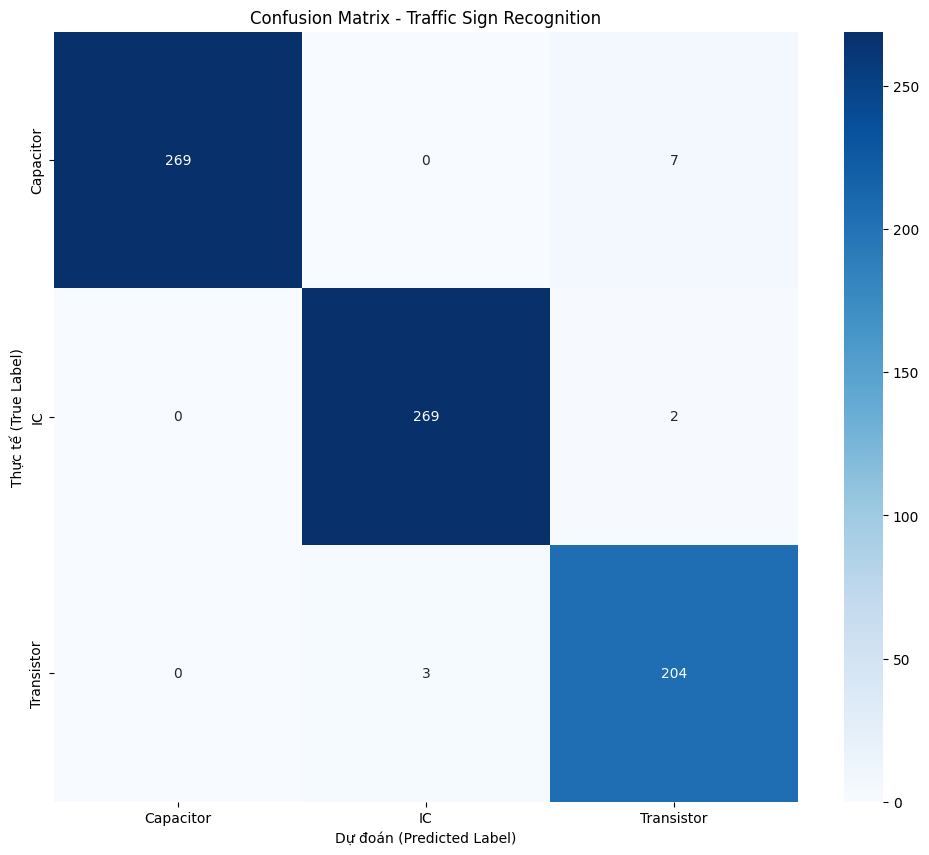

In [18]:
# ------------------------------------------------------------------
# 4. MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ------------------------------------------------------------------
print("\n--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Traffic Sign Recognition')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
/content/drive/MyDrive/test/image_1776600660.jpg → IC (99.96%)


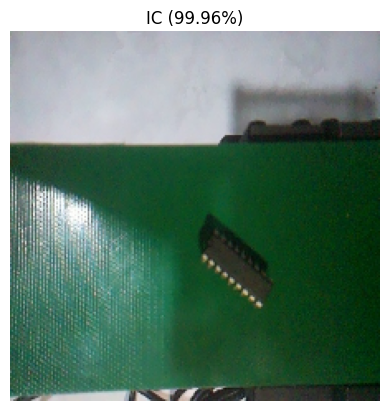

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/my_model.h5')
image_paths = ['/content/drive/MyDrive/test/image_1776600660.jpg']

for file_name in image_paths:
    try:
        img = image.load_img(file_name, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        pred = model.predict(img_array)
        label = class_names[np.argmax(pred)]
        conf = np.max(pred) * 100

        print(f"{file_name} → {label} ({conf:.2f}%)")

        plt.imshow(img)
        plt.title(f"{label} ({conf:.2f}%)")
        plt.axis("off")
        plt.show()

    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file tại đường dẫn: {file_name}. Bạn đã kiểm tra lại tên hoặc vị trí chưa?")
    except Exception as e:
        print(f"Đã xảy ra lỗi với file {file_name}: {e}")